<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-10-22 11:45:11--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  65.5MB/s    in 3.1s    

2025-10-22 11:45:16 (65.5 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


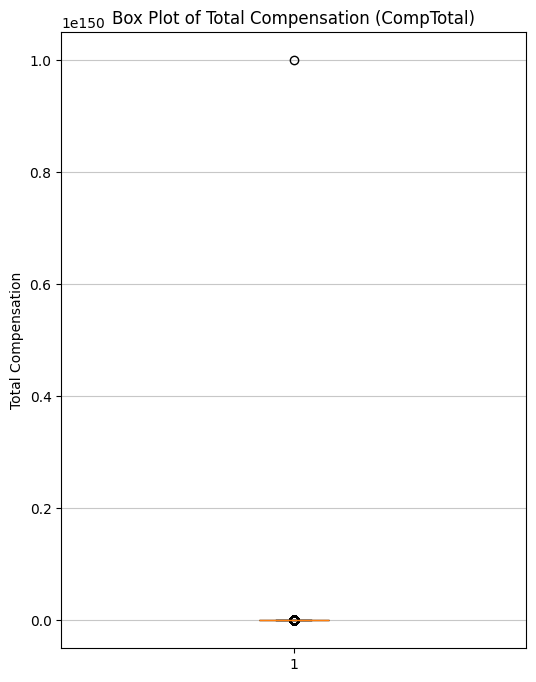

In [8]:
QUERY = """
SELECT CompTotal
FROM main
WHERE CompTotal IS NOT NULL;
"""
df_comp = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(6,8))
plt.boxplot(df_comp['CompTotal'], vert=True, patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Box Plot of Total Compensation (CompTotal)')
plt.ylabel('Total Compensation')
plt.grid(axis='y', alpha=0.7)
plt.show()


The column CompTotal contains a large number of missing or invalid values, making it unreliable for accurate statistical analysis or comparison. It should be cleaned, imputed, or excluded from further analysis to avoid misleading results.

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


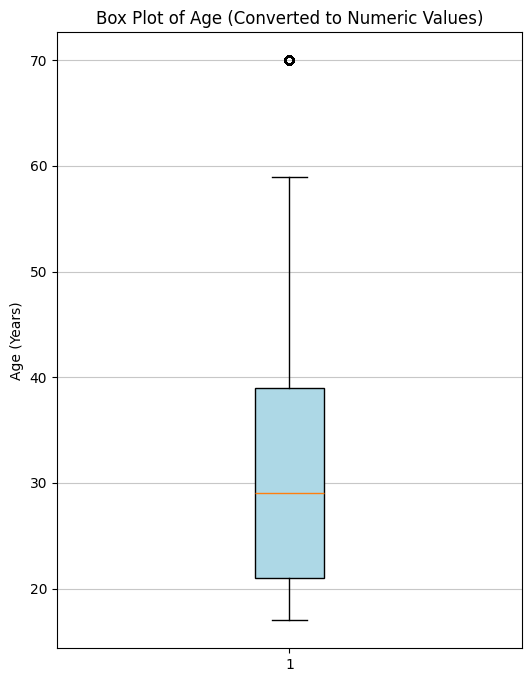

In [14]:
data = {
    'Age': [
        '18-24 years old', '25-34 years old', '35-44 years old',
        '45-54 years old', '55-64 years old', '65 years or older',
        'Prefer not to say', 'Under 18 years old'
    ],
    'count': [14098, 23911, 14942, 6249, 2575, 772, 322, 2568]
}

df_age = pd.DataFrame(data)

age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70,
    'Prefer not to say': None
}

df_age['AgeNumeric'] = df_age['Age'].map(age_map)

df_expanded = df_age.loc[df_age.index.repeat(df_age['count'])]

plt.figure(figsize=(6,8))
plt.boxplot(df_expanded['AgeNumeric'].dropna(), vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Age (Converted to Numeric Values)')
plt.ylabel('Age (Years)')
plt.grid(axis='y', alpha=0.7)
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1000x600 with 0 Axes>

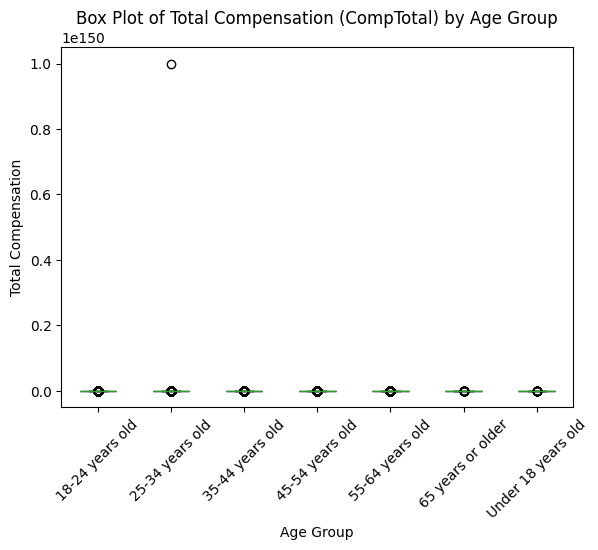

In [15]:
# your code goes here
QUERY = """
SELECT Age, CompTotal
FROM main
WHERE CompTotal IS NOT NULL AND Age IS NOT NULL;
"""
df = pd.read_sql_query(QUERY, conn)

age_order = [
    'Under 18 years old', '18-24 years old', '25-34 years old',
    '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older'
]
df = df[df['Age'].isin(age_order)]

plt.figure(figsize=(10,6))
df.boxplot(column='CompTotal', by='Age', grid=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Total Compensation (CompTotal) by Age Group')
plt.suptitle('')  
plt.xlabel('Age Group')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


<Figure size 1000x600 with 0 Axes>

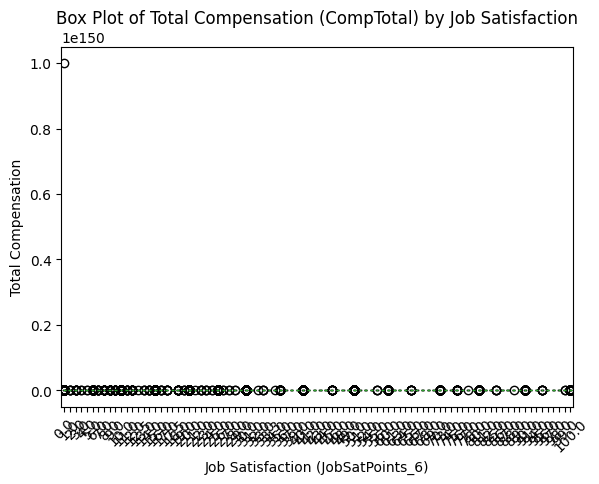

In [18]:
QUERY = """
SELECT JobSatPoints_6, CompTotal
FROM main
WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL;
"""
df = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10,6))
df.boxplot(column='CompTotal', by='JobSatPoints_6', grid=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Total Compensation (CompTotal) by Job Satisfaction')
plt.suptitle('')  # Removes extra subtitle
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45)
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


<Figure size 1000x600 with 0 Axes>

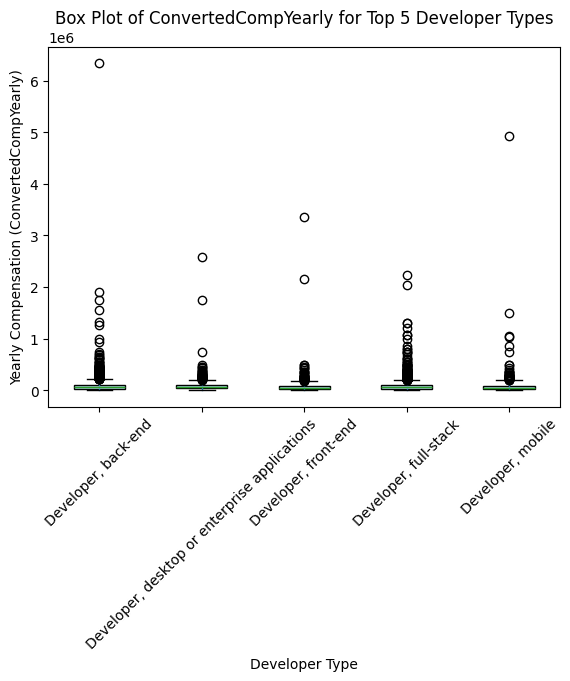

In [19]:
QUERY = """
SELECT DevType, ConvertedCompYearly
FROM main
WHERE ConvertedCompYearly IS NOT NULL AND DevType IS NOT NULL;
"""
df = pd.read_sql_query(QUERY, conn)

top5_devtypes = df['DevType'].value_counts().head(5).index
df_top5 = df[df['DevType'].isin(top5_devtypes)]


plt.figure(figsize=(10,6))
df_top5.boxplot(column='ConvertedCompYearly', by='DevType', grid=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of ConvertedCompYearly for Top 5 Developer Types')
plt.suptitle('')
plt.xlabel('Developer Type')
plt.ylabel('Yearly Compensation (ConvertedCompYearly)')
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


<Figure size 1000x600 with 0 Axes>

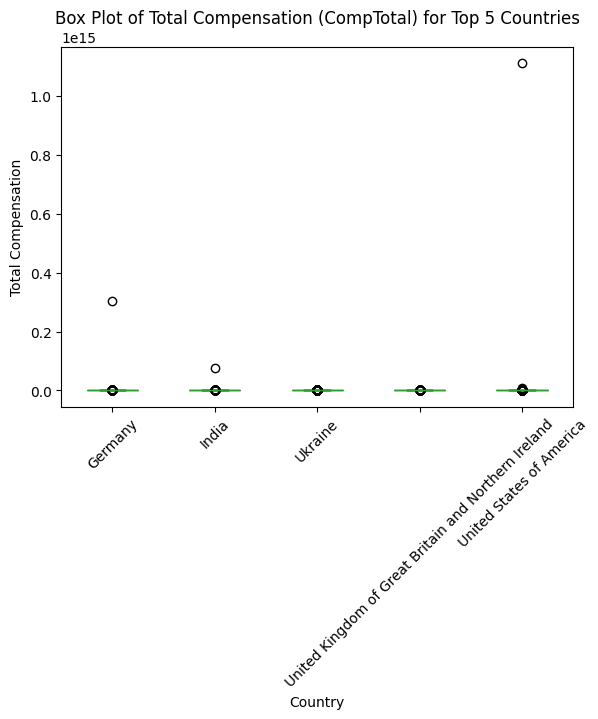

In [20]:
QUERY = """
SELECT Country, CompTotal
FROM main
WHERE CompTotal IS NOT NULL AND Country IS NOT NULL;
"""
df = pd.read_sql_query(QUERY, conn)

# Get top 5 countries by number of respondents
top5_countries = df['Country'].value_counts().head(5).index
df_top5 = df[df['Country'].isin(top5_countries)]

plt.figure(figsize=(10,6))
df_top5.boxplot(column='CompTotal', by='Country', grid=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Total Compensation (CompTotal) for Top 5 Countries')
plt.suptitle('')
plt.xlabel('Country')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45)
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


<Figure size 2000x1200 with 0 Axes>

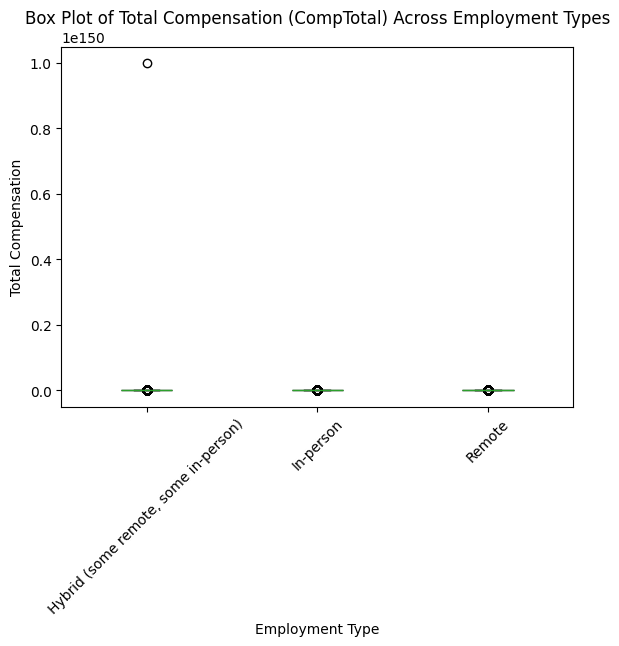

In [24]:
QUERY = """
SELECT RemoteWork, CompTotal
FROM main
WHERE CompTotal IS NOT NULL AND Employment IS NOT NULL;
"""
df = pd.read_sql_query(QUERY, conn)

# Plot box plot
plt.figure(figsize=(20,12))
df.boxplot(column='CompTotal', by='RemoteWork', grid=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Total Compensation (CompTotal) Across Employment Types')
plt.suptitle('')
plt.xlabel('Employment Type')
plt.ylabel('Total Compensation')
plt.xticks(rotation=45)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [27]:
QUERY = """
SELECT DISTINCT YearsCodePro
FROM main
WHERE YearsCodePro IS NOT NULL
ORDER BY YearsCodePro;
"""

df_years = pd.read_sql_query(QUERY, conn)

# Print the distinct values
print(df_years)

          YearsCodePro
0                    1
1                   10
2                   11
3                   12
4                   13
5                   14
6                   15
7                   16
8                   17
9                   18
10                  19
11                   2
12                  20
13                  21
14                  22
15                  23
16                  24
17                  25
18                  26
19                  27
20                  28
21                  29
22                   3
23                  30
24                  31
25                  32
26                  33
27                  34
28                  35
29                  36
30                  37
31                  38
32                  39
33                   4
34                  40
35                  41
36                  42
37                  43
38                  44
39                  45
40                  46
41                  47
42         

<Figure size 1000x600 with 0 Axes>

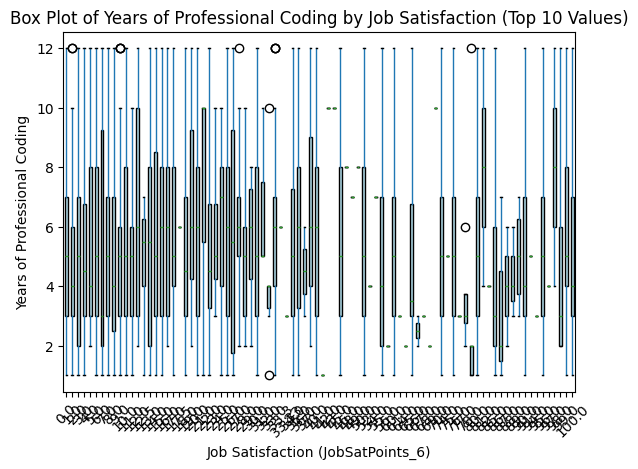

In [31]:
QUERY = """
SELECT YearsCodePro, JobSatPoints_6
FROM main
WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL;
"""
df = pd.read_sql_query(QUERY, conn)

# Convert YearsCodePro to numeric, handle special cases
df['YearsCodeProNumeric'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df.loc[df['YearsCodePro'] == 'Less than 1 year', 'YearsCodeProNumeric'] = 0.5
df.loc[df['YearsCodePro'] == 'More than 50 years', 'YearsCodeProNumeric'] = 51

# Keep only the 10 most frequent YearsCodePro values
top10_values = df['YearsCodeProNumeric'].value_counts().head(10).index
df_top10 = df[df['YearsCodeProNumeric'].isin(top10_values)]

# Plot box plot
plt.figure(figsize=(10,6))
df_top10.boxplot(column='YearsCodeProNumeric', by='JobSatPoints_6', grid=False, patch_artist=True,
                 boxprops=dict(facecolor='lightblue'))
plt.title('Box Plot of Years of Professional Coding by Job Satisfaction (Top 10 Values)')
plt.suptitle('')
plt.xlabel('Job Satisfaction (JobSatPoints_6)')
plt.ylabel('Years of Professional Coding')
plt.xticks(rotation=45)
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [ ]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
